# Setup

## Setup Environment

Run the following command to setup the environment and use the respecitve kernel in Jupyther.

```bash
conda create -n SOS2025 python=3.11 -y
conda activate SOS2025
pip install -r requirements.txt
```

## Load Libraries

In [1]:
# Import Starvers for the provenance documentation. 
# Import the libraries required for the exercise, e.g., pandas, numpy, scipy, matplotlib, seaborn and scikit-learn
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import plotly.express as px
import datetime
import typing
import requests
import time
import shutil
import json
from starvers.starvers import TripleStoreEngine
from scipy.io import arff
import uuid

## Provenance Configuration

In [3]:
executed_by = 'stud-id_12022505'  # Replace the digits after "id_" with your own student ID
# executed_by = 'stud-id_01541209'  # Replace the digits after "id_" with your own student ID


# group id for this project
group_id = '25'  # Replace the digits with your group id

# Students working on this notebook
student_a = 'stud-id_12022505'  # Replace the digits after "id_" with student A's student ID
raphael = student_a
student_b = 'stud-id_01541209'  # Replace the digits after "id_" with student B's student ID
anton = student_b

# Roles. Don't change these values.
code_writer_role = 'code_writer'
code_executor_role = 'code_executor'

# according to the forum we switch to the BI endpoints
# get_endpoint = "https://starvers.ec.tuwien.ac.at/SOS2025"
# post_endpoint = "https://starvers.ec.tuwien.ac.at/SOS2025/statements"

get_endpoint = "https://starvers.ec.tuwien.ac.at/BI2025"
post_endpoint = "https://starvers.ec.tuwien.ac.at/BI2025/statements"
engine = TripleStoreEngine(get_endpoint, post_endpoint, skip_connection_test=True)

prefixes = {
    'xsd': 'http://www.w3.org/2001/XMLSchema#',
    'foaf': 'http://xmlns.com/foaf/0.1/',
    'prov': 'http://www.w3.org/ns/prov#',
    'sc': 'https://schema.org/',
    'cr': 'http://mlcommons.org/croissant/',
    'mls': 'http://www.w3.org/ns/mls#',
    'mlso': 'http://w3id.org/mlso',
    'siu': 'https://si-digital-framework.org/SI/units/',
    'siq': 'https://si-digital-framework.org/SI/quantities/',
    'qudt': 'http://qudt.org/schema/qudt/',
    '': f'https://starvers.ec.tuwien.ac.at/SOS2025/{group_id}/',
}

### Registration
ONLY RUN ONCE! And i already did that!

In [ ]:
raise(Exception("Registration triples have already been inserted. Do not run this cell again!

Ontologies used: foaf, prov, IAO
reigstration_triples_a = [
f':{student_a} rdf:type foaf:Person .',
f':{student_a} rdf:type prov:Agent .',
f':{student_a} foaf:givenName "Raphael" .',
f':{student_a} foaf:familyName "Dick" .',
f':{student_a} <http://vivoweb.org/ontology/core#identifier> :{student_a} .',
f':{student_a} rdf:type <http://purl.obolibrary.org/obo/IAO_0000578> .',
f':{student_a} <http://www.w3.org/2000/01/rdf-schema#label> "Immatriculation number" .',
f':{student_a} <http://purl.obolibrary.org/obo/IAO_0000219> "12022505"^^xsd:string .',
]

reigstration_triples_b = [
f':{student_b} rdf:type foaf:Person .',
f':{student_b} rdf:type prov:Agent .',
f':{student_b} foaf:givenName "Anton" .',
f':{student_b} foaf:familyName "Stoiber" .',
f':{student_b} <http://vivoweb.org/ontology/core#identifier> :{student_b} .',
f':{student_b} rdf:type <http://purl.obolibrary.org/obo/IAO_0000578> .',
f':{student_b} <http://www.w3.org/2000/01/rdf-schema#label> "Immatriculation number" .',
f':{student_b} <http://purl.obolibrary.org/obo/IAO_0000219> "01541209"^^xsd:string .',
]

role_triples = [
    f':{code_writer_role} rdf:type prov:Role .',
    f':{code_executor_role} rdf:type prov:Role .',
]

engine.insert(reigstration_triples_a, prefixes=prefixes)
engine.insert(reigstration_triples_b, prefixes=prefixes)
engine.insert(role_triples, prefixes=prefixes)

Exception: ### Registration triples have already been inserted. Do not run this cell again! ###

# Helper Scripts

In [11]:
# GENERATE UUID
# ---
# Execute this cell to generate a new uuid that you can use instead of blank nodes
# for e.g. activities, executors, writers, ...

print(uuid.uuid4())

2d5816b4-fdc2-4dee-9b73-a09572ca3f7b


# Helper Functions

In [4]:
def now() -> str:
    """
    Returns the current time in ISO 8601 format with UTC timezone in the following format:
    YYYY-MM-DDTHH:MM:SS.sssZ
    """
    timestamp = datetime.datetime.now(datetime.timezone.utc)
    timestamp_formated = timestamp.strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3]  +"Z"

    return timestamp_formated

def executor_triplets(activity_id: str, executor_uuid: str):
	return [
    f':{activity_id} prov:qualifiedAssociation :{executor_uuid} .',
    f':{executor_uuid} prov:agent :{executed_by} .',
    f':{executor_uuid} rdf:type prov:Association .',
    f':{executor_uuid} prov:hadRole :{code_executor_role} .',
	]

def writer_triplets(activity_id: str, writer_id: str, writer_uuid: str, ):
	return [
    f':{activity_id} prov:qualifiedAssociation :{writer_uuid} .',
    f':{writer_uuid} prov:agent :{writer_id} .',
    f':{writer_uuid} rdf:type prov:Association .',
    f':{writer_uuid} prov:hadRole :{code_writer_role} .',
	]

def phase_triplets(phase_id: str, name: str):
	return [
		f':{phase_id} rdf:type prov:Activity .',
		f':{phase_id} rdfs:label "{name}" .', 
	]

def activity_base_triplets(activity_id: str, phase_id: str, name: str, report: str, start_time: str, end_time: str):
	return [
    f':{activity_id} rdf:type prov:Activity .',
    f':{activity_id} sc:isPartOf :{phase_id} .',
    f':{activity_id} rdfs:comment \'{name}\' .',
    f':{activity_id} rdfs:comment """{report}""" .', 
    f':{activity_id} prov:startedAtTime "{start_time}"^^xsd:dateTime .',
    f':{activity_id} prov:endedAtTime "{end_time}"^^xsd:dateTime .',
	]



# Data Understanding

In [13]:
# Prov
prov__data_understanding_phase = "data_understanding_phase"
engine.insert(phase_triplets(prov__data_understanding_phase, "Data Understanding Phase"), prefixes=prefixes)

## Load Data

In [5]:
# Config
data_path = os.path.join("data", "datasets")

# Functions
def load_arff_data(file_name: str) -> pd.DataFrame:

	### Load your data
	input_file = os.path.join(data_path, file_name)

	# load data from .arff file
	arff_file = arff.loadarff(input_file)
	raw_data = pd.DataFrame(arff_file[0])

	loaded_data = raw_data
	
	return loaded_data


# Execution
start_time = now()
data = load_arff_data("dataset_14_mfeat-fourier.arff")
end_time = now()

In [15]:
# Provenance
# Describe the data loading activity
prov__du__load_data = "du__load_data"

engine.insert([
	*executor_triplets(prov__du__load_data, "f7a8b191-9068-44d5-8b2c-42c510db48fa"),
	*writer_triplets(prov__du__load_data, raphael, "dd355588-c291-4a28-b803-75af3892db87"),
	*activity_base_triplets(
		prov__du__load_data,
		prov__data_understanding_phase,
		"Load Data",
		"""
			Load the dataset obtained from OpenML, from .arff format into a pandas dataframe
		""",
		start_time,
		end_time
	),
	*[ # inputs
    f':{prov__du__load_data} prov:used :raw_data .',
    f':{prov__du__load_data} prov:used :raw_data_path .',
    f':raw_data rdf:type prov:Entity .',
    f':raw_data_path rdf:type prov:Entity .',
    f':raw_data prov:wasDerivedFrom :raw_data_path .',
	],
	*[ # outputs
    f':data rdf:type prov:Entity .',
    f':data prov:wasGeneratedBy :{prov__du__load_data} .',
    f':data prov:wasDerivedFrom :raw_data .',
	]
], prefixes=prefixes)

## Describing the Raw data

In [16]:
def feature_field(i: int):
	return [
		f':raw_recordset cr:field :field_att{i} .',
		f':field_att{i} rdf:type cr:Field .',
		f':field_att{i} sc:name \'Attribute {i}\' .',
		f':field_att{i} sc:description \'This field describes feature {i} of handwritten numberals\' .',
		f':field_att{i} cr:dataType xsd:float .',
	]

engine.insert([
	':raw_data rdf:type sc:Dataset .',
	':raw_data sc:name \'mfeat-fourier\' .',
	':raw_data sc:description \'One of a set of 6 datasets describing features of handwritten numerals (0 - 9) extracted from a collection of Dutch utility maps. Corresponding patterns in different datasets correspond to the same original character. 200 instances per class (for a total of 2,000 instances) have been digitized in binary images.\' .',

	':data_arff rdf:type cr:FileObject .',
	':data_arff sc:name \'dataset_14_mfeat-fourier.arff\' .',
	':data_arff sc:encodingFormat \'text/arff\' .',
	':raw_data sc:distribution :data_arff .',

	':raw_recordset rdf:type cr:RecordSet .',
	':raw_recordset sc:name \'Table of features of handwritter numerals (0-9)\' .',
	':raw_recordset cr:source :data_arff .',
	':raw_data cr:recordSet :raw_recordset .',

	# Class
	':raw_recordset cr:field :field_class .',
	':field_class rdf:type cr:Field .',
	':field_class sc:name \'Class (target)\' .',
	':field_class sc:description \'The target class consisting of 10 distinct nominal values (1 to 10)\' .',
	':field_class cr:dataType xsd:int .',

	# Features (att1 - att76)
	*[field for i in range(1, 77) for field in feature_field(i)],
], prefixes=prefixes)

In [17]:
# Provenance
prov__du__describing_raw_data = "du__describing_raw_data"

start_time = now()
end_time = now()

engine.insert([
	*executor_triplets(prov__du__describing_raw_data, "f7611786-1a2b-407d-a6d4-292e03e927d0"),
	*writer_triplets(prov__du__describing_raw_data, raphael, "1c9c335f-d5c6-41c6-935f-4aa181b1518e"),
	*activity_base_triplets(
		prov__du__describing_raw_data,
		prov__data_understanding_phase,
		"Describe Raw Data",
		"""
			Added provenance information describing the raw data loaded from the .arff file into a pandas dataframe, and related information
		""",
		start_time,
		end_time
	),
	*[ # inputs
    f':{prov__du__describing_raw_data} prov:used :raw_data .',
	]
], prefixes=prefixes)

## Describing the Data

In [18]:
engine.insert([
	':data rdf:type sc:Dataset .',
	':recordset rdf:type cr:RecordSet .',
	':data cr:recordSet :recordset .',

	':recordset cr:field :field_class .',
	*[field for i in range(1, 77) for field in [
		f':recordset cr:field :field_att{i} .'
	]]
], prefixes=prefixes)

In [19]:
# Provenance
prov__du__describing_data = "du__describing_data"

start_time = now()
end_time = now()

engine.insert([
	*executor_triplets(prov__du__describing_data, "bd2e7a4b-9bd0-42fb-b8f6-1408a78c575a"),
	*writer_triplets(prov__du__describing_data, raphael, "45b533ae-f03b-4723-8fb0-824b696e7d5e"),
	*activity_base_triplets(
		prov__du__describing_data,
		prov__data_understanding_phase,
		"Describe Data",
		"""
			Added provenance information describing the data loaded and related information
		""",
		start_time,
		end_time
	),
	*[ # inputs
    f':{prov__du__describing_data} prov:used :data .',
	]
], prefixes=prefixes)

## Extending the descriptions

In [20]:
def field_characteristics(field_name: str, characteristics: typing.Dict[str, typing.Any]) -> typing.List[str]:
	triplets = [
		f':field_{field_name} cr:hasCharacteristic :field_{field_name}_characteristics .',
		f':field_{field_name}_characteristics rdf:type cr:FieldCharacteristics .',
	]

	for char_name, char_value in characteristics.items():
		char_value_str = str(char_value).replace('\'', '\\\'').replace('\"', '\\"')
		triplets.append(f':field_{field_name}_characteristics cr:{char_name} \'{char_value_str}\' .')

	return triplets

def calculate_feature_characteristics(data: pd.DataFrame, field_name: str) -> typing.Dict[str, typing.Any]:
	characteristics = {}

	series = data[field_name]

	characteristics['minValue'] = series.min()
	characteristics['maxValue'] = series.max()
	characteristics['meanValue'] = series.mean()
	characteristics['standardDeviation'] = series.std()
	characteristics['numberOfMissingValues'] = series.isna().sum()
	characteristics['sparsity'] = series.isna().sum() / len(series)
	characteristics['numberOfUniqueValues'] = series.nunique()
	characteristics['numberOfOutliers'] = ((series < (series.mean() - 3 * series.std())) | (series > (series.mean() + 3 * series.std()))).sum()
	characteristics['correlationWithClass'] = data[[field_name, 'class']].corr().iloc[0,1]

	return characteristics

feature_characteristics_triplets = []

for i in range(1, 77):
	field_name = f'att{i}'
	characteristics = calculate_feature_characteristics(data, field_name)
	field_triplets = field_characteristics(field_name, characteristics)
	feature_characteristics_triplets.extend(field_triplets)

engine.insert(feature_characteristics_triplets, prefixes=prefixes)

In [21]:
# Provenance
prov__du__field_characteristics = "du__field_characteristics"

engine.insert([
	*executor_triplets(prov__du__field_characteristics, "baa60518-50c9-449c-858a-2ec5dd9536c6"),
	*writer_triplets(prov__du__field_characteristics, raphael, "a213895a-179e-454a-8e98-a870a8a3f3cb"),
	*activity_base_triplets(
		prov__du__field_characteristics,
		prov__data_understanding_phase,
		"Extend Field with Field Characteristics",
		"""
			Added provenance information describing the field characteristics of the data, thereby calculating
			- minValue
			- maxValue
			- meanValue
			- standardDeviation
			- numberOfMissingValues (absolute number of missing values)
			- sparsity (proportion of missing values)
			- numberOfUniqueValues (number of unique values)
			- numberOfOutliers (values outside mean +/- 3*std)
			- correlationWithClass (Pearson correlation with the target class)
		""",
		start_time,
		end_time
	),
	*[ # inputs
    f':{prov__du__describing_data} prov:used :data .',
	]
], prefixes=prefixes)

## More Analysation & Characteristics

In [22]:
# Dataset/recordset size (overall rows/cols)
engine.insert([
    ':recordset cr:size "2000"^^xsd:int .',      # total rows
    ':data sc:numberOfVariables "77"^^xsd:int .',# features + class
], prefixes=prefixes)


In [23]:
start_time = now()
rows, cols = data.shape
overall_missing = int(data.isna().sum().sum())
overall_sparsity = overall_missing / (rows * cols)
class_counts = data['class'].value_counts().to_dict()
hypothesis = """Expect ~10 clusters (digits 0-9); some overlap among similar digits; class balance per counts above."""
end_time = now()

In [24]:
# Provenance
prov__du__dataset_characteristics = "du__dataset_characteristics"
engine.insert([
    *executor_triplets(prov__du__dataset_characteristics, "b71a3e54-32d3-4dbd-85f5-08cfa273be7f"),
    *writer_triplets(prov__du__dataset_characteristics, anton, "b3436372-d238-4f93-af8c-95bcee4c44b2"),
    *activity_base_triplets(
        prov__du__dataset_characteristics,
        prov__data_understanding_phase,
        "Dataset-level characteristics",
        f"rows={rows}, cols={cols}, missing={overall_missing}, sparsity={overall_sparsity:.4f}, class_dist={class_counts}",
        start_time,
        end_time
    ),
    f':{prov__du__dataset_characteristics} prov:used :data .',
    ':data sc:comment """' + hypothesis + '""" .'
], prefixes=prefixes)


In [25]:
engine.insert([
    f':data sc:additionalProperty "overall_missing={overall_missing}, overall_sparsity={overall_sparsity:.4f}" .'
], prefixes=prefixes)


# Data Preparation

In [26]:
prov__data_preparation_phase = "data_preparation_phase"
engine.insert(phase_triplets(prov__data_preparation_phase, "Data Preparation Phase"), prefixes=prefixes)

## Splitting the Data into x & y + Normalization

In [6]:
from sklearn.preprocessing import StandardScaler

# --- preprocess
start_time = now()
X = data.drop(columns=['class']).values   # features
y = data['class'].values                  # labels (kept unchanged)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
end_time = now()


In [28]:
# --- provenance
prov__dp__scaling_standard = "dp__scaling_standard"  # unique ID for this prep step
engine.insert([
    *executor_triplets(prov__dp__scaling_standard, "fc0989d6-7c98-4393-a10d-9d9920481480"),
    *writer_triplets(prov__dp__scaling_standard, anton, "6acc6786-dbac-49c8-b007-ffeca427a85b"),
    *activity_base_triplets(
        prov__dp__scaling_standard,
        prov__data_preparation_phase,
        "Standardize features",
        "StandardScaler (mean=0, std=1) on 76 features; class unchanged.",
        start_time,
        end_time
    ),
    f':{prov__dp__scaling_standard} prov:used :data .',
    ':scaled_data rdf:type sc:Dataset .',
    ':scaled_data sc:name "mfeat-fourier scaled" .',
    ':scaled_data cr:recordSet :recordset_scaled .',
    f':{prov__dp__scaling_standard} prov:generated :scaled_data .'
], prefixes=prefixes)

## More Data Preperation Considerations


In [7]:
def prepare_data(data: pd.DataFrame) -> pd.DataFrame:
	# TRANSCODING
	# not needed as all features are already in numeric format

	# FEATURE SELECTION / DIMENSIONALITY REDUCTION
	# no feature selection or dimensionality reduction applied, because 76 features is manageable

	# SUBSAMPLING
	# only 2000 samples, what is relatively small => no subsampling needed

	# MISSING VALUES
	# no missing values at all (see data understanding phase)

	# OUTLIER DETECTION
	# 372 rows (of 2000) contain at least one outlier (mean +/- 3*std)
	# we keep the outliers for further analysis with the SOM
	# because it would bei ~18% of the data that would be removed otherwise
	# and we want to see how the SOM handles outliers
	# Removing outliers may distort the cluster structure more than keeping them

	# Summing up: besides scaling (and dropping the class label),
	# we do not apply any other data preparation steps,
	# as the data is already in a good preprocessed state,
	# and thereby viable for SOM training
	return data


def findAllOutliers(data: pd.DataFrame, threshold: float = 3) -> pd.DataFrame:
	"""
	Find all outliers in the data using the mean +/- {{threshold}}*std rule
	we used this function to check how many outliers are in the data for a given threshold
	"""
	outliers = pd.DataFrame()
	for column in data.columns:
		series = data[column]
		mean = series.mean()
		std = series.std()
		lower_bound = mean - threshold * std
		upper_bound = mean + threshold * std	
		outlier_rows = data[(series < lower_bound) | (series > upper_bound)]
		outliers = pd.concat([outliers, outlier_rows])
	
	return outliers.drop_duplicates()

# print("Outliers found:")
# print(findAllOutliers(pd.DataFrame(X_scaled), threshold=3))

# we drop the class (target) column as SOMs are unsupervised methods
# outliers: mean - 3 * std

start_time = now()
prepared_data = prepare_data(pd.DataFrame(X_scaled))
end_time = now()


In [30]:
# Provenance
prov__dp__other_preparation = "dp__other_preparation"

engine.insert([
	*executor_triplets(prov__dp__other_preparation, "37243142-9488-44d7-83c4-570540ca31c0"),
	*writer_triplets(prov__dp__other_preparation, raphael, "936b24c7-f61d-43b5-8c6a-3cb125269597"),
	*activity_base_triplets(
		prov__dp__other_preparation,
		prov__data_preparation_phase,
		"Consider other data preparation steps",
		"""
			We considered the following data preparation steps:
			- TRANSCODING
				Transcoding is not needed, as all features (except the dropped class labels) are already in numeric format

			- FEATURE SELECTION / DIMENSIONALITY REDUCTION
				We did not apply feature selection or dimensionality reduction, because 76 features is manageable for SOMs,
				and we want to preserve the original feature space for better interpretability, and usability of feature characteristics

			- SUBSAMPLING
				As the dataset only contains 2000 samples, which is relatively small, no subsampling is needed or makes sense.

			- MISSING VALUES
				As discovered during the data understanding phase, there are no missing values in the dataset,
				therefore no imputation or removal of rows is needed.

			- OUTLIER DETECTION
				372 rows (out of 2000) are outliers in at least one feature (based on the: mean +/- 3*std metric).
				As this is a significant portion of the data (18.6%),
				we keep the outliers for further analysis with the SOM.
				We want to see how the SOM handles outliers,
				and SOMs are generally quite robust to outliers (compared to other clustering methods).
				Removing outliers may distort the cluster structure more than keeping them.

			Summing up:
			besides scaling (and dropping the class label), we do not apply any other data preparation steps,
			as the data is already in a good preprocessed state, and thereby viable for SOM training
		""",
		start_time,
		end_time
	),
	*[ # inputs
    f':{prov__du__describing_data} prov:used :data .',
	]
], prefixes=prefixes)

# SOM Training and Analysis

In [8]:
'''
1)
Train a reasonably sized „regular“ SOM
-
Train a SOM with „regular“ size (i.e. number of units as a certain fraction of the number of data items) and reasonable training parameters (sufficiently large initial neighborhood, learning rate; provide a justification for the selection of the parameters. NOTE: Learning rates for SOMs differ from those usually encountered in Deep Neural Networks, c.f. lecture)

-
Analyse in detail the class distribution, cluster structure, quantization errors, topology violations.
    a) Can you identify the border effect and magnification factors.
    b) How well do class distribution and cluster structure match?
    c) Which classes fall into sub-clusters, which classes are split across clusters, which classes mix in clusters.
    d) How is the quantization error distributed on the map, how does this correspond with perceived cluster separation and quality?
-
Describe and compare the structures found (providing detailed info on visualizations and parameters)
'''
import os, sys
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.append(repo_root)

from SOMToolbox.minisom import MiniSom
import numpy as np

def train_som(X, y, m, n, sigma, lr, iters, seed):
    som = MiniSom(m, n, X.shape[1], sigma=sigma, learning_rate=lr,
                  neighborhood_function='gaussian', random_seed=seed)
    som.train_random(X, iters)
    weights = som.get_weights()
    qe = som.quantization_error(X)

    def topo_err_manual(som, X):
        W = som.get_weights().reshape(-1, X.shape[1])  # (m*n, dim)
        m, n = som._weights.shape[:2]
        err = 0
        for v in X:
            dists = np.linalg.norm(W - v, axis=1)
            bmu_idx = np.argmin(dists)
            dists[bmu_idx] = np.inf
            bmu2_idx = np.argmin(dists)
            bmu = (bmu_idx // n, bmu_idx % n)
            bmu2 = (bmu2_idx // n, bmu2_idx % n)
            if abs(bmu[0]-bmu2[0]) + abs(bmu[1]-bmu2[1]) > 1:  # not adjacent
                err += 1
        return err / len(X)

    te = topo_err_manual(som, X)
    bmus = [som.winner(v) for v in X]
    return som, weights, qe, te, bmus

m, n = 15, 15  # rule of thumb ~224 neurons
sigma, lr, iters, seed = 1.5, 0.5, 5000, 42
start_time = now()
som, weights, qe, te, bmus = train_som(X_scaled, y, m, n, sigma, lr, iters, seed)
end_time = now()
print(f"QE={qe:.4f}, TE={te:.4f}, map={m}x{n}, sigma={sigma}, lr={lr}, iters={iters}, seed={seed}")


QE=5.6034, TE=0.3350, map=15x15, sigma=1.5, lr=0.5, iters=5000, seed=42


In [11]:
import matplotlib.pyplot as plt
import os
os.makedirs("outputs", exist_ok=True)

# U-matrix (using the provided class)
import sys, os
repo_root = os.path.abspath("..")  # parent of provenance_documentation
som_root = os.path.abspath("../SOMToolbox")
for p in (repo_root, som_root):
    if p not in sys.path:
        sys.path.append(p)

from SOMToolbox.visualizations.umatrix import UMatrix

U = UMatrix.calculate_UMatrix(weights, m, n, X_scaled.shape[1])
plt.imshow(U, cmap="viridis")
plt.colorbar()
plt.title("U-Matrix (regular SOM)")
plt.savefig("outputs/regular_umatrix.png", dpi=200)
plt.close()

# Hit histogram per neuron (simple count)
hits = np.zeros((m, n))
for b in bmus:
    hits[b] += 1
plt.imshow(hits, cmap="magma")
plt.colorbar()
plt.title("Hit Histogram (counts)")
plt.savefig("outputs/regular_hits.png", dpi=200)
plt.close()

# Quantization error per neuron (average distance for samples mapped to each BMU)
qe_map = np.zeros((m, n))
counts = np.zeros((m, n))
for v, b in zip(X_scaled, bmus):
    qe_map[b] += np.linalg.norm(v - som.get_weights()[b])
    counts[b] += 1
qe_map = np.divide(qe_map, counts, out=np.zeros_like(qe_map), where=counts>0)
plt.imshow(qe_map, cmap="inferno")
plt.colorbar()
plt.title("QE per neuron")
plt.savefig("outputs/regular_qe_map.png", dpi=200)
plt.close()


# Justification for Gridsize, Neighbourhood radius, and Learning Rate:

Map size: 5·√N rule → 5·√2000 ≈ 224 neurons → 15×15 = 225 (regular size).

Learning rate (0.5): Moderate step size for SOMs; higher than typical DL LR because SOM updates are neighborhood-averaged; decays over iterations.

Sigma (1.5): Initial neighborhood ~10% of grid span; wide enough for global ordering, small enough to preserve cluster detail after decay.



In [ ]:
try:
    prov__modeling_phase
except NameError:
    prov__modeling_phase = "modeling_phase"
    engine.insert(phase_triplets(prov__modeling_phase, "Modeling Phase"), prefixes=prefixes)


In [38]:
# --- provenance (Regular SOM, Task C1)
prov__mod__regular_som = "mod__regular_som"  # activity ID

desc = (
    f"{m}x{n}, sigma={sigma}, lr={lr}, iters={iters}, seed={seed}, "
    f"qe={qe:.4f}, te={te:.4f}; "
    "size from 5*sqrt(N)≈224→15x15; lr 0.5 for moderate SOM step; "
    "sigma 1.5 for broad initial neighborhood."
)

engine.insert([
    *executor_triplets(prov__mod__regular_som, "5dfd5856-6580-4227-9c0b-daa83c58298a"),
    *writer_triplets(prov__mod__regular_som, anton, "7540c0eb-cbff-4f58-bd28-6163a325d07a"),
    *activity_base_triplets(
        prov__mod__regular_som,
        prov__modeling_phase,
        "Train regular SOM",
        desc,
        start_time,
        end_time
    ),
    f':{prov__mod__regular_som} prov:used :scaled_data .',
    f':{prov__mod__regular_som} prov:generated :mod__regular_som_weights .',
    ':mod__regular_som_weights rdf:type cr:FileObject .',
    ':mod__regular_som_weights sc:encodingFormat "npy" .',

    f':{prov__mod__regular_som} prov:generated :regular_umatrix_png .',
    ':regular_umatrix_png rdf:type cr:FileObject .',
    ':regular_umatrix_png sc:name "outputs/regular_umatrix.png" .',
    ':regular_umatrix_png sc:encodingFormat "image/png" .',

    f':{prov__mod__regular_som} prov:generated :regular_hits_png .',
    ':regular_hits_png rdf:type cr:FileObject .',
    ':regular_hits_png sc:name "outputs/regular_hits.png" .',
    ':regular_hits_png sc:encodingFormat "image/png" .',

    f':{prov__mod__regular_som} prov:generated :regular_qe_map_png .',
    ':regular_qe_map_png rdf:type cr:FileObject .',
    ':regular_qe_map_png sc:name "outputs/regular_qe_map.png" .',
    ':regular_qe_map_png sc:encodingFormat "image/png" .'
], prefixes=prefixes)


In [ ]:
'''
2)
Analyze different initializations of the SOM:
-
Train one further „regular-sized“ SOM using the same training parameters as above, but using a different random seed for initializing the SOM.
-
Show and describe a) how the cluster structures and class distributions shift on the two SOMs, b) the effect on topology violations, cluster relationships, etc. c) Which clusters show a stable relationship, which ones change their relative position? d) Which data instances are stably mapped with similar data instances, which change a lot? Are they part of the same clusters?
-
Describe and compare the structures found (providing detailed info on visualizations and parameters)
3)
Analyze different map sizes:
-
Train 2 additional SOMs varying the size (very small / very large) (provide reasons for choice of sizes)
-
Train each map with rather large neighborhood radius and high learning rate (provide reasons for the definition of „high“!)
-
Analyse in detail the a) class distribution, b) cluster structure, c) quantization errors, d) topology violations. Also, e) analyze how clusters shift, change in relative size, and how their relative position to each other changes or remains the same. f) Check for aspects such as magnification factors. What is the resulting granularity of clusters visible on the small and large maps? Are the same clusters visible in the very large map as in the regular map?
-
Describe and compare the structures found (providing detailed info on visualizations and parameters)
'''


In [ ]:

'''
4)
Analyze different initial neighborhood radius settings:
-
Train the very large SOM as specified above, but with a much too small neighborhood radius.
-
Analyse the a) cluster structure, b) quantization errors, c) topology violations. d) In how far does this map differ from the very large map trained with a correct/high initial neighborhood radius?
-
Describe and compare the structures found (what is the effect of a „too small“ neighborhood radius? How to detect it?)
5)
Analyze different initial learning rates:
-
Train the regular-sized SOM as specified above, but with a (I) much too large / (II) much too small learning rate (provide justification for the setting of the parameter)
-
Analyse for both (I) and (II) a) cluster structure, b) quantization errors, c) topology violations. d) In how far do these two maps differ from the well-trained map analyzed above?
-
Describe and compare the structures found (how can you detect „too small“ learning rates? When do they start to make sense?
6)
Analyze different max iterations:
-
Train a regular SOM using 2, 5, 10, 50, 100, 1000, 5000, 10000 iterations
-
Analyse cluster structure. a) When do cluster structures start to emerge? b) After how many iterations do they stabilize? c) How can you tell from the quality measures whether the map is stable? d) Which visualizations help you discover not-yet stable SOM mappings?
-
Describe and compare the structures found (what is the effect of a „too low“ number of iterations, when does it start to converge properly/lead to reasonable structures?)
7)
Detailed analysis of an „Optimal SOM“:
188.413 Self-Organizing Systems(VU 3.0)
HandsOn Assignments: SOM – Data Exploration
-
Train a SOM using what you consider to be „optimal parameters“ based on sub-tasks 1-6.
-
Describe the final model following MLSO.
-
Provide a detailed interpretation of the cluster/class structures using a combination of visualizations and their parameter settings. Describe the findings in detail, specifically analyzing and providing rationale for
a.
Cluster densities / cardinalities, shapes: what can you tell about the cluster sizes shapes, their cardinalities and densities? Can you observe areas of higher/lower densities? Compare different visualizations that support (or contradict) your hypothesis and reason/explain why they do so.
b.
Hierarchical cluster relationships: can you detect any hierarchies in the data? How do they seem to be structured? Which clusters are similar, which are very distant, how could they be related? Compare different visualizations that support (or contradict) your hypothesis and reason/explain why they do so.
c.
Topological relations / violations: in which areas can you observe topology violations? What types of violations do you observe in which areas of the map (i.e. actual violations due to bad training or the inherent structure of the data vs. cluster data that is mapped onto the plane). In how far do different visualizations agree on these violations? Compare different visualizations that support (or contradict) your hypothesis and reason/explain why they do so.
d.
Class distribution: Which classes are mapped onto which parts of the map? How do they relate to each other? In how far does the class distribution match the cluster structure? Which classes are well-separated, which ones less so? What might be the reason for these overlaps? Is the mapping less correct in these regions (e.g. higher error measures)? Are these areas well-separated. Which classes form homogeneous clusters, which form sub-clusters, how similar are these sub-clusters?
e.
Quality of the map in terms of vector quantization and topology violation: is the quality homogeneous, are there certain areas or classes where the quality of the mapping is lower, others where it is higher?'''

## C.4) Analyze different initial neighborhood radius settings

- Train the very large SOM as specified above, but with a much too small neighborhood radius.
- Analyse the
  - a) cluster structure
  - b) quantization errors
  - c) topology violations
  - d) In how far does this map differ from the very large map trained with a correct/high initial neighborhood radius?
- Describe and compare the structures found (what is the effect of a „too small“ neighborhood radius? How to detect it?)


## C.5) Analyze different initial learning rates:
- Train the regular-sized SOM as specified above, but with a (I) much too large / (II) much too small learning rate (provide justification for the setting of the parameter)
- Analyse for both (I) and (II)
  - a) cluster structure
  - b) quantization errors
  - c) topology violations
  - d) In how far do these two maps differ from the well-trained map analyzed above?
- Describe and compare the structures found (how can you detect „too small“ learning rates? When do they start to make sense?

## C.6) Analyze different max iterations:
- Train a regular SOM using 2, 5, 10, 50, 100, 1000, 5000, 10000 iterations
- Analyse cluster structure.
  - a) When do cluster structures start to emerge?
  - b) After how many iterations do they stabilize?
  - c) How can you tell from the quality measures whether the map is stable?
  - d) Which visualizations help you discover not-yet stable SOM mappings?
- Describe and compare the structures found (what is the effect of a „too low“ number of iterations, when does it start to converge properly/lead to reasonable structures?)

Iterations: 2, QE=8.1147, TE=0.8675


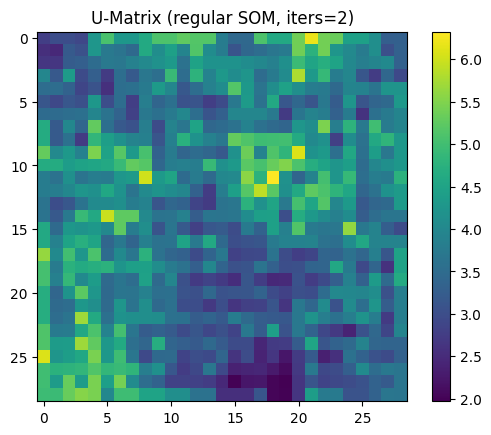

Iterations: 5, QE=8.0315, TE=0.8720


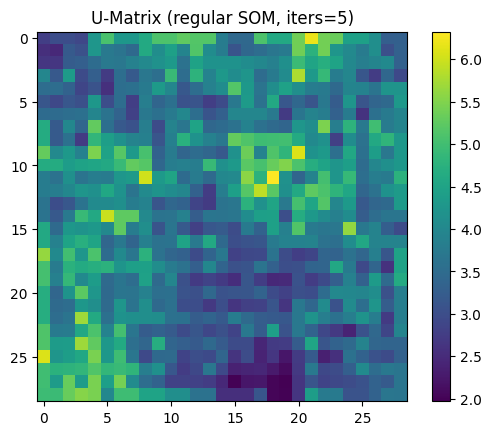

Iterations: 10, QE=7.9342, TE=0.8790


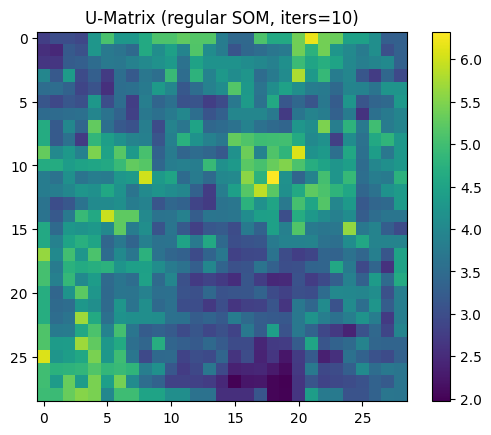

Iterations: 50, QE=7.8092, TE=0.8785


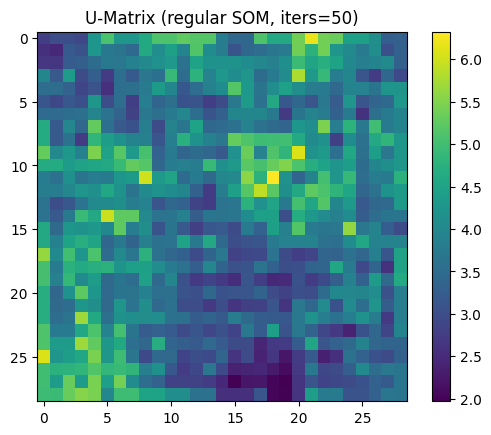

Iterations: 100, QE=7.7479, TE=0.8675


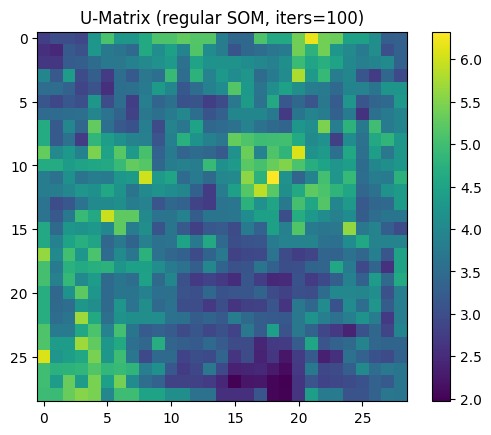

Iterations: 1000, QE=6.4202, TE=0.3370


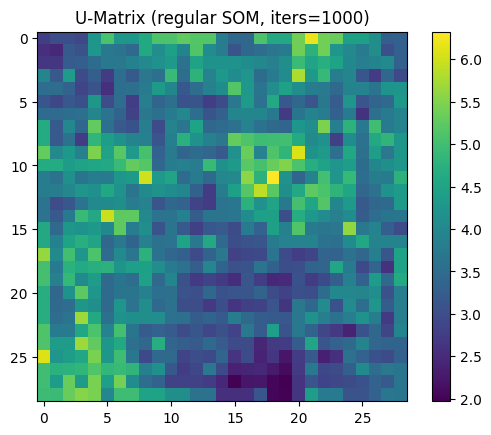

Iterations: 5000, QE=5.6034, TE=0.3350


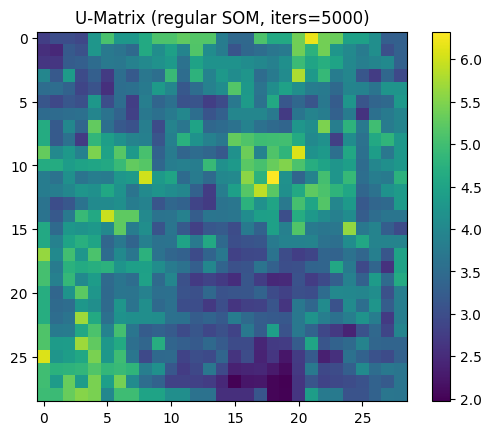

Iterations: 10000, QE=5.5234, TE=0.3195


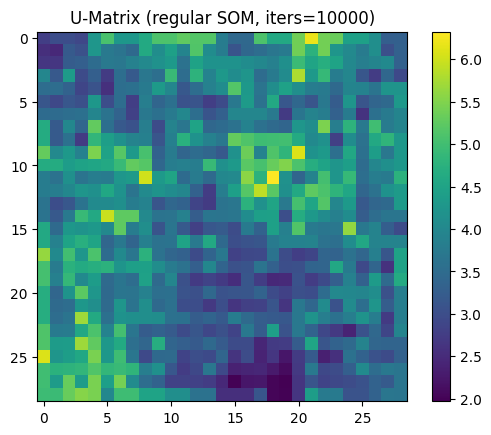

In [ ]:
# default setting from C.1)
m, n = 15, 15
sigma, lr, seed = 1.5, 0.5, 42


def perform_iteration_analysis(iterations):
	som, weights, qe, te, bmus = train_som(X_scaled, y, m, n, sigma, lr, iterations, seed)

	U = UMatrix.calculate_UMatrix(weights, m, n, X_scaled.shape[1])
	plt.figure()
	plt.imshow(U, cmap="viridis")
	plt.colorbar()
	plt.title(f"U-Matrix (regular SOM, iters={iterations})")
	# output in notebook
	plt.show()
	plt.close()

	print(f"Iterations: {iterations}, QE={qe:.4f}, TE={te:.4f}")

iterations_list = [2, 5, 10, 50, 100, 1000, 5000, 10000]

for iterations in iterations_list:
	perform_iteration_analysis(iterations)


